# thickLSTO standalone notebook

このnotebookは、src由来の単体化版です。外部ライブラリ以外のpackage importを使わず、最大厚み制約つきレベルセット・トポロジー最適化を1ファイルで実行できるように展開しています。

In [1]:
from collections.abc import Callable
from dataclasses import dataclass, replace
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from scipy import sparse
from scipy.sparse import linalg as sparse_linalg
from scipy.sparse import linalg as spla


## Core data structures

In [2]:
@dataclass(frozen=True)
class Mesh:
    """Finite-element mesh.

    Args:
        nodes: Node coordinates, shape ``(n_nodes, dim)``, units of length.
        elements: Element connectivity, shape ``(n_elements, n_elem_nodes)``.
        dim: Spatial dimension. Initial implementation supports ``dim == 2``.
        element_type: Element family. Initial implementation supports ``"Rect4"``.
    """
    nodes: np.ndarray
    elements: np.ndarray
    dim: int
    element_type: str = 'Rect4'

    def __post_init__(self) -> None:
        nodes = np.asarray(self.nodes, dtype=float)
        elements = np.asarray(self.elements, dtype=int)
        if nodes.ndim != 2:
            raise ValueError('nodes must have shape (n_nodes, dim)')
        if elements.ndim != 2:
            raise ValueError('elements must have shape (n_elements, n_elem_nodes)')
        if self.dim != nodes.shape[1]:
            raise ValueError('dim must match nodes.shape[1]')
        if self.dim != 2:
            raise ValueError('only 2D meshes are supported')
        if self.element_type != 'Rect4':
            raise ValueError('only Rect4 elements are supported')
        if elements.shape[1] != 4:
            raise ValueError('Rect4 elements must have 4 nodes')
        if elements.size and (elements.min() < 0 or elements.max() >= nodes.shape[0]):
            raise ValueError('elements contain node indices outside nodes')
        object.__setattr__(self, 'nodes', nodes)
        object.__setattr__(self, 'elements', elements)

    @property
    def n_nodes(self) -> int:
        """Number of nodes."""
        return int(self.nodes.shape[0])

    @property
    def n_elements(self) -> int:
        """Number of elements."""
        return int(self.elements.shape[0])

    @property
    def n_dofs(self) -> int:
        """Number of 2D displacement degrees of freedom."""
        return self.n_nodes * self.dim

@dataclass(frozen=True)
class LevelSetState:
    """Level-set state.

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
        time: Pseudo-time.
    """
    phi: np.ndarray
    time: float = 0.0

    def __post_init__(self) -> None:
        phi = np.asarray(self.phi, dtype=float)
        if phi.ndim != 1:
            raise ValueError('phi must have shape (n_nodes,)')
        object.__setattr__(self, 'phi', phi)

@dataclass(frozen=True)
class RDParams:
    """Reaction-diffusion update parameters.

    Args:
        tau: Regularization coefficient.
        length_scale: Characteristic length ``L``.
        dt: Pseudo-time step.
        k0: Constant update coefficient ``K``.
        c: Sensitivity normalization scale.
        v_max: Maximum material volume.
        lambda_value: Fixed Lagrange multiplier for the initial implementation.
    """
    tau: float
    length_scale: float
    dt: float
    k0: float
    c: float
    v_max: float
    lambda_value: float = 0.0

    def __post_init__(self) -> None:
        if self.tau < 0:
            raise ValueError('tau must be non-negative')
        if self.length_scale <= 0:
            raise ValueError('length_scale must be positive')
        if self.dt <= 0:
            raise ValueError('dt must be positive')
        if self.k0 <= 0:
            raise ValueError('k0 must be positive')
        if self.c <= 0:
            raise ValueError('c must be positive')


@dataclass(frozen=True)
class Material:
    """Isotropic material.

    Args:
        young: Young's modulus, force per area.
        poisson: Poisson's ratio.
        density: Mass density.
        void_ratio: Ersatz material stiffness ratio ``d``.
    """
    young: float
    poisson: float
    density: float = 1.0
    void_ratio: float = 0.001

    def __post_init__(self) -> None:
        if self.young <= 0:
            raise ValueError('young must be positive')
        if not -1.0 < self.poisson < 0.5:
            raise ValueError('poisson must be in (-1, 0.5)')
        if self.density <= 0:
            raise ValueError('density must be positive')
        if not 0.0 < self.void_ratio <= 1.0:
            raise ValueError('void_ratio must be in (0, 1]')

    def elasticity_matrix(self, plane_stress: bool=True) -> np.ndarray:
        """Return the 2D elasticity matrix.

        Args:
            plane_stress: Use plane-stress if true, plane-strain otherwise.
        Returns:
            Elasticity matrix, shape ``(3, 3)``, force per area.
        """
        e = self.young
        nu = self.poisson
        if plane_stress:
            factor = e / (1.0 - nu * nu)
            return factor * np.array([[1.0, nu, 0.0], [nu, 1.0, 0.0], [0.0, 0.0, (1.0 - nu) / 2.0]])
        factor = e / ((1.0 + nu) * (1.0 - 2.0 * nu))
        return factor * np.array([[1.0 - nu, nu, 0.0], [nu, 1.0 - nu, 0.0], [0.0, 0.0, (1.0 - 2.0 * nu) / 2.0]])


def structured_rect4_mesh(lx: float, ly: float, nx: int, ny: int) -> Mesh:
    xs = np.linspace(0.0, lx, nx + 1)
    ys = np.linspace(0.0, ly, ny + 1)
    nodes = np.array([[x, y] for y in ys for x in xs], dtype=float)
    elements = []
    for j in range(ny):
        for i in range(nx):
            n0 = j * (nx + 1) + i
            elements.append([n0, n0 + 1, n0 + nx + 2, n0 + nx + 1])
    return Mesh(nodes=nodes, elements=np.asarray(elements, dtype=int), dim=2)


## Heaviside and constraints

In [3]:
def characteristic(phi: np.ndarray) -> np.ndarray:
    """Return the characteristic function from equation (3).

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
    Returns:
        Material indicator, shape ``(n_nodes,)``, values in ``{0, 1}``.
    """
    values = np.asarray(phi, dtype=float)
    return (values >= 0.0).astype(float)

def heaviside_material_sharp(phi: np.ndarray, d: float) -> np.ndarray:
    """Return equation (62), the sharp Ersatz material Heaviside.

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
        d: Void-to-solid material ratio.
    Returns:
        Ersatz material scale, shape ``(n_nodes,)``, values in ``[d, 1]``.
    """
    if not 0.0 < d <= 1.0:
        raise ValueError('d must be in (0, 1]')
    values = np.asarray(phi, dtype=float)
    return np.where(values < 0.0, d, 1.0)

def heaviside_material_smooth(phi: np.ndarray, d: float, w: float) -> np.ndarray:
    """Return equation (63), the smooth Ersatz material Heaviside.

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
        d: Void-to-solid material ratio.
        w: Transition half-width, dimensionless.
    Returns:
        Ersatz material scale, shape ``(n_nodes,)``, values in ``[d, 1]``.
    """
    if not 0.0 < d <= 1.0:
        raise ValueError('d must be in (0, 1]')
    if w <= 0.0:
        raise ValueError('w must be positive')
    values = np.asarray(phi, dtype=float)
    out = np.empty_like(values, dtype=float)
    out[values <= -w] = d
    out[values >= w] = 1.0
    mask = (values > -w) & (values < w)
    x = values[mask] / w
    smooth = 0.5 + x * (15.0 / 16.0 - x * x * (5.0 / 8.0 - 3.0 / 16.0 * x * x))
    out[mask] = smooth * (1.0 - d) + d
    return out

def heaviside_volume(phi: np.ndarray) -> np.ndarray:
    """Return equation (65), the volume Heaviside.

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
    Returns:
        Volume fraction values, shape ``(n_nodes,)``, values in ``[0, 1]``.
    """
    values = np.asarray(phi, dtype=float)
    out = np.empty_like(values, dtype=float)
    out[values <= -1.0] = 0.0
    out[values >= 1.0] = 1.0
    mask = (values > -1.0) & (values < 1.0)
    x = values[mask]
    out[mask] = 0.5 + x / 2.0 * (15.0 / 16.0 - x * x / 4.0 * (5.0 / 8.0 - 3.0 / 64.0 * x * x))
    return np.clip(out, 0.0, 1.0)


def clip_phi(phi: np.ndarray) -> np.ndarray:
    """Clip equation (59) to enforce the level-set bound.

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
    Returns:
        Clipped level-set values, shape ``(n_nodes,)``, values in ``[-1, 1]``.
    """
    return np.clip(np.asarray(phi, dtype=float), -1.0, 1.0)

def volume(phi: np.ndarray, weights: np.ndarray) -> float:
    """Return material volume using equation (65).

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
        weights: Nodal integration weights, shape ``(n_nodes,)``, units of area.
    Returns:
        Material volume, units of area in 2D.
    """
    phi_values = np.asarray(phi, dtype=float)
    weight_values = np.asarray(weights, dtype=float)
    if phi_values.shape != weight_values.shape:
        raise ValueError('phi and weights must have the same shape')
    return float(np.dot(heaviside_volume(phi_values), weight_values))

def volume_constraint(phi: np.ndarray, weights: np.ndarray, v_max: float) -> float:
    """Return equation (64), ``G(phi) = volume(phi) - V_max``.

    Args:
        phi: Level-set values, shape ``(n_nodes,)``, dimensionless.
        weights: Nodal integration weights, shape ``(n_nodes,)``, units of area.
        v_max: Maximum allowed material volume, units of area in 2D.
    Returns:
        Constraint value. Feasible values are less than or equal to zero.
    """
    return volume(phi, weights) - float(v_max)

material_volume = volume
material_volume_constraint = volume_constraint


## Rect4 finite element utilities

In [4]:
GAUSS_2 = (-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0))

@dataclass(frozen=True)
class Rect4Precompute:
    """Mesh-only precomputed quantities for axis-aligned Rect4 elements."""
    element_dofs: np.ndarray
    stiffness_rows: np.ndarray
    stiffness_cols: np.ndarray
    scalar_rows: np.ndarray
    scalar_cols: np.ndarray
    b_matrices: np.ndarray
    shape_values: np.ndarray
    shape_gradients: np.ndarray
    det_j: np.ndarray
    areas: np.ndarray
    nodal_weights: np.ndarray

def element_dofs(element: np.ndarray, dim: int=2) -> np.ndarray:
    """Return displacement DOF indices for an element.

    Args:
        element: Node indices, shape ``(4,)`` for ``Rect4``.
        dim: Spatial dimension. Initial implementation supports ``2``.
    Returns:
        Degree-of-freedom indices, shape ``(8,)``.
    """
    if dim != 2:
        raise ValueError('only 2D displacement DOFs are supported')
    nodes = np.asarray(element, dtype=int)
    dofs = np.empty(nodes.size * dim, dtype=int)
    dofs[0::2] = nodes * dim
    dofs[1::2] = nodes * dim + 1
    return dofs

def validate_rect4_coords(coords: np.ndarray) -> np.ndarray:
    """Validate standard-order axis-aligned Rect4 coordinates.

    Args:
        coords: Element coordinates, shape ``(4, 2)``, ordered as
            lower-left, lower-right, upper-right, upper-left.
    Returns:
        Coordinates converted to float, shape ``(4, 2)``.
    """
    xy = np.asarray(coords, dtype=float)
    if xy.shape != (4, 2):
        raise ValueError('Rect4 coordinates must have shape (4, 2)')
    x0, y0 = xy[0]
    x1, y1 = xy[1]
    x2, y2 = xy[2]
    x3, y3 = xy[3]
    if not (np.isclose(y0, y1) and np.isclose(x1, x2) and np.isclose(y2, y3) and np.isclose(x3, x0)):
        raise ValueError('Rect4 coordinates must be axis-aligned and in standard order')
    if not (x1 > x0 and x2 > x3 and (y3 > y0) and (y2 > y1)):
        raise ValueError('Rect4 element must have positive width and height')
    return xy

def rect4_area(coords: np.ndarray) -> float:
    """Return the area of a standard-order Rect4 element.

    Args:
        coords: Element coordinates, shape ``(4, 2)``, units of length.
    Returns:
        Element area, units of area.
    """
    xy = validate_rect4_coords(coords)
    return float((xy[1, 0] - xy[0, 0]) * (xy[3, 1] - xy[0, 1]))

def rect4_shape_functions(xi: float, eta: float) -> np.ndarray:
    """Return bilinear Rect4 shape functions.

    Args:
        xi: Reference coordinate in ``[-1, 1]``.
        eta: Reference coordinate in ``[-1, 1]``.
    Returns:
        Shape function values, shape ``(4,)``.
    """
    return 0.25 * np.array([(1.0 - xi) * (1.0 - eta), (1.0 + xi) * (1.0 - eta), (1.0 + xi) * (1.0 + eta), (1.0 - xi) * (1.0 + eta)], dtype=float)

def rect4_shape_gradients_reference(xi: float, eta: float) -> np.ndarray:
    """Return Rect4 shape gradients in reference coordinates.

    Args:
        xi: Reference coordinate in ``[-1, 1]``.
        eta: Reference coordinate in ``[-1, 1]``.
    Returns:
        Gradients with columns ``d/dxi`` and ``d/deta``, shape ``(4, 2)``.
    """
    return 0.25 * np.array([[-(1.0 - eta), -(1.0 - xi)], [1.0 - eta, -(1.0 + xi)], [1.0 + eta, 1.0 + xi], [-(1.0 + eta), 1.0 - xi]], dtype=float)

def rect4_shape_gradients(coords: np.ndarray, xi: float, eta: float) -> tuple[np.ndarray, float]:
    """Return Rect4 shape gradients in physical coordinates.

    Args:
        coords: Element coordinates, shape ``(4, 2)``, units of length.
        xi: Reference coordinate in ``[-1, 1]``.
        eta: Reference coordinate in ``[-1, 1]``.
    Returns:
        Tuple ``(gradients, det_j)`` where gradients has shape ``(4, 2)`` and
        columns ``d/dx`` and ``d/dy``.
    """
    xy = validate_rect4_coords(coords)
    dndr = rect4_shape_gradients_reference(xi, eta)
    jacobian = dndr.T @ xy
    det_j = float(np.linalg.det(jacobian))
    if det_j <= 0.0:
        raise ValueError('Rect4 element has non-positive Jacobian')
    return (dndr @ np.linalg.inv(jacobian), det_j)

def rect4_b_matrix(coords: np.ndarray, xi: float, eta: float) -> tuple[np.ndarray, float]:
    """Return the strain-displacement matrix for a Rect4 element.

    Args:
        coords: Element coordinates, shape ``(4, 2)``, units of length.
        xi: Reference coordinate in ``[-1, 1]``.
        eta: Reference coordinate in ``[-1, 1]``.
    Returns:
        Tuple ``(B, det_j)`` where ``B`` has shape ``(3, 8)``.
    """
    grads, det_j = rect4_shape_gradients(coords, xi, eta)
    b = np.zeros((3, 8), dtype=float)
    for i, (dn_dx, dn_dy) in enumerate(grads):
        b[0, 2 * i] = dn_dx
        b[1, 2 * i + 1] = dn_dy
        b[2, 2 * i] = dn_dy
        b[2, 2 * i + 1] = dn_dx
    return (b, det_j)

def nodal_integration_weights(mesh: Mesh, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Return lumped nodal area weights.

    Args:
        mesh: Rect4 mesh.
    Returns:
        Nodal area weights, shape ``(n_nodes,)``, units of area.
    """
    if precompute is not None:
        return precompute.nodal_weights.copy()
    weights = np.zeros(mesh.n_nodes, dtype=float)
    for element in mesh.elements:
        area = rect4_area(mesh.nodes[element])
        weights[element] += area / 4.0
    return weights

def precompute_rect4(mesh: Mesh) -> Rect4Precompute:
    """Precompute mesh-only Rect4 quantities reused across optimization steps."""
    if mesh.dim != 2:
        raise ValueError('only 2D Rect4 precomputation is supported')
    n_elements = mesh.n_elements
    q_points = [(xi, eta) for xi in GAUSS_2 for eta in GAUSS_2]
    dofs = np.empty((n_elements, 8), dtype=int)
    stiffness_rows = np.empty((n_elements, 64), dtype=int)
    stiffness_cols = np.empty((n_elements, 64), dtype=int)
    scalar_rows = np.empty((n_elements, 16), dtype=int)
    scalar_cols = np.empty((n_elements, 16), dtype=int)
    b_matrices = np.empty((n_elements, len(q_points), 3, 8), dtype=float)
    shape_gradients = np.empty((n_elements, len(q_points), 4, 2), dtype=float)
    det_j = np.empty((n_elements, len(q_points)), dtype=float)
    areas = np.empty(n_elements, dtype=float)
    nodal_weights = np.zeros(mesh.n_nodes, dtype=float)
    shape_values = np.array([rect4_shape_functions(xi, eta) for xi, eta in q_points], dtype=float)
    for e_index, element in enumerate(mesh.elements):
        coords = mesh.nodes[element]
        dof_values = element_dofs(element, mesh.dim)
        dofs[e_index] = dof_values
        rr, cc = np.meshgrid(dof_values, dof_values, indexing='ij')
        stiffness_rows[e_index] = rr.ravel()
        stiffness_cols[e_index] = cc.ravel()
        sr, sc = np.meshgrid(element, element, indexing='ij')
        scalar_rows[e_index] = sr.ravel()
        scalar_cols[e_index] = sc.ravel()
        areas[e_index] = rect4_area(coords)
        nodal_weights[element] += areas[e_index] / 4.0
        for q_index, (xi, eta) in enumerate(q_points):
            b, det = rect4_b_matrix(coords, xi, eta)
            grads, _ = rect4_shape_gradients(coords, xi, eta)
            b_matrices[e_index, q_index] = b
            shape_gradients[e_index, q_index] = grads
            det_j[e_index, q_index] = det
    return Rect4Precompute(element_dofs=dofs, stiffness_rows=stiffness_rows, stiffness_cols=stiffness_cols, scalar_rows=scalar_rows, scalar_cols=scalar_cols, b_matrices=b_matrices, shape_values=shape_values, shape_gradients=shape_gradients, det_j=det_j, areas=areas, nodal_weights=nodal_weights)

def assemble_stiffness(mesh: Mesh, material: Material, material_scale: np.ndarray | None=None, thickness: float=1.0, plane_stress: bool=True, precompute: Rect4Precompute | None=None) -> sparse.csr_matrix:
    """Assemble equation (61), the Ersatz stiffness matrix.

    Args:
        mesh: Rect4 mesh.
        material: Isotropic material.
        material_scale: Nodal Ersatz scale ``H_a(phi)``, shape ``(n_nodes,)``.
        thickness: Out-of-plane thickness.
        plane_stress: Use plane-stress material matrix if true.
    Returns:
        Global stiffness matrix, shape ``(n_dofs, n_dofs)``.
    """
    scale = np.ones(mesh.n_nodes, dtype=float) if material_scale is None else np.asarray(material_scale, dtype=float)
    if scale.shape != (mesh.n_nodes,):
        raise ValueError('material_scale must have shape (n_nodes,)')
    dmat = material.elasticity_matrix(plane_stress=plane_stress)
    if precompute is not None:
        elem_scale = np.mean(scale[mesh.elements], axis=1)
        btdb = np.einsum('eqai,ab,eqbj->eqij', precompute.b_matrices, dmat, precompute.b_matrices)
        ke_base = np.einsum('eqij,eq->eij', btdb, precompute.det_j)
        ke = elem_scale[:, None, None] * float(thickness) * ke_base
        return sparse.coo_matrix((ke.ravel(), (precompute.stiffness_rows.ravel(), precompute.stiffness_cols.ravel())), shape=(mesh.n_dofs, mesh.n_dofs)).tocsr()
    rows: list[int] = []
    cols: list[int] = []
    data: list[float] = []
    for element in mesh.elements:
        coords = mesh.nodes[element]
        elem_scale = float(np.mean(scale[element]))
        ke = np.zeros((8, 8), dtype=float)
        for xi in GAUSS_2:
            for eta in GAUSS_2:
                b, det_j = rect4_b_matrix(coords, xi, eta)
                ke += elem_scale * thickness * (b.T @ dmat @ b) * det_j
        dofs = element_dofs(element, mesh.dim)
        rr, cc = np.meshgrid(dofs, dofs, indexing='ij')
        rows.extend(rr.ravel().tolist())
        cols.extend(cc.ravel().tolist())
        data.extend(ke.ravel().tolist())
    return sparse.coo_matrix((data, (rows, cols)), shape=(mesh.n_dofs, mesh.n_dofs)).tocsr()

def assemble_load(mesh: Mesh, body_force: np.ndarray | None=None, material_scale: np.ndarray | None=None, nodal_forces: dict[int, np.ndarray] | None=None, thickness: float=1.0, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Assemble equation (61), the load vector.

    Args:
        mesh: Rect4 mesh.
        body_force: Constant body force, shape ``(2,)``, force per area.
        material_scale: Nodal material scale for body force, shape ``(n_nodes,)``.
        nodal_forces: Optional nodal point forces keyed by node index, each shape ``(2,)``.
        thickness: Out-of-plane thickness.
    Returns:
        Global load vector, shape ``(n_dofs,)``.
    """
    f = np.zeros(mesh.n_dofs, dtype=float)
    scale = np.ones(mesh.n_nodes, dtype=float) if material_scale is None else np.asarray(material_scale, dtype=float)
    if scale.shape != (mesh.n_nodes,):
        raise ValueError('material_scale must have shape (n_nodes,)')
    if body_force is not None:
        bf = np.asarray(body_force, dtype=float)
        if bf.shape != (2,):
            raise ValueError('body_force must have shape (2,)')
        if precompute is not None:
            elem_scale = np.mean(scale[mesh.elements], axis=1)
            nodal_integrals = np.einsum('qi,eq,e->ei', precompute.shape_values, precompute.det_j, elem_scale)
            fe = np.zeros((mesh.n_elements, 8), dtype=float)
            fe[:, 0::2] = nodal_integrals * bf[0] * float(thickness)
            fe[:, 1::2] = nodal_integrals * bf[1] * float(thickness)
            np.add.at(f, precompute.element_dofs.ravel(), fe.ravel())
        else:
            for element in mesh.elements:
                coords = mesh.nodes[element]
                fe = np.zeros(8, dtype=float)
                elem_scale = float(np.mean(scale[element]))
                for xi in GAUSS_2:
                    for eta in GAUSS_2:
                        n = rect4_shape_functions(xi, eta)
                        _, det_j = rect4_shape_gradients(coords, xi, eta)
                        for i in range(4):
                            fe[2 * i:2 * i + 2] += n[i] * bf * elem_scale * thickness * det_j
                f[element_dofs(element, mesh.dim)] += fe
    if nodal_forces:
        for node, force in nodal_forces.items():
            vec = np.asarray(force, dtype=float)
            if vec.shape != (2,):
                raise ValueError('nodal force must have shape (2,)')
            if node < 0 or node >= mesh.n_nodes:
                raise ValueError('nodal force references an unknown node')
            f[2 * node:2 * node + 2] += vec
    return f


## Objectives and reaction-diffusion update

In [5]:
@dataclass(frozen=True)
class ObjectiveResult:
    """Objective evaluation result.

    Args:
        value: Objective value.
        sensitivity: Sensitivity values, shape ``(n_nodes,)``.
    """
    value: float
    sensitivity: np.ndarray

@dataclass(frozen=True)
class RegularizedObjectiveValue:
    """Regularized minimum-compliance objective components."""
    compliance: float
    volume: float
    volume_constraint: float
    volume_lagrange_term: float
    interface_energy: float
    lagrangian: float
    regularized_lagrangian: float

def compliance(u: np.ndarray, f: np.ndarray) -> float:
    """Return the mean-compliance objective ``l(u)``.

    Args:
        u: Displacement vector, shape ``(n_dofs,)``.
        f: Load vector, shape ``(n_dofs,)``.
    Returns:
        Compliance scalar, force times length.
    """
    displacement = np.asarray(u, dtype=float)
    load = np.asarray(f, dtype=float)
    if displacement.shape != load.shape:
        raise ValueError('u and f must have the same shape')
    return float(np.dot(load, displacement))

def interface_energy(mesh: Mesh, phi: np.ndarray, tau: float, length_scale: float, precompute: Rect4Precompute | None=None) -> float:
    """Return ``0.5 * tau * L^2 * integral |grad(phi)|^2 dOmega``.

    Args:
        mesh: Rect4 mesh.
        phi: Level-set values, shape ``(n_nodes,)``.
        tau: Regularization coefficient.
        length_scale: Characteristic length ``L``.
    Returns:
        Interface energy scalar.
    """
    if tau < 0.0:
        raise ValueError('tau must be non-negative')
    if length_scale <= 0.0:
        raise ValueError('length_scale must be positive')
    phi_values = np.asarray(phi, dtype=float)
    if phi_values.shape != (mesh.n_nodes,):
        raise ValueError('phi must have shape (n_nodes,)')
    if tau == 0.0:
        return 0.0
    coefficient = 0.5 * float(tau) * float(length_scale) ** 2
    if precompute is not None:
        elem_phi = phi_values[mesh.elements]
        grad_phi = np.einsum('eqia,ei->eqa', precompute.shape_gradients, elem_phi)
        return float(coefficient * np.sum(np.einsum('eqa,eqa->eq', grad_phi, grad_phi) * precompute.det_j))
    energy = 0.0
    for element in mesh.elements:
        coords = mesh.nodes[element]
        elem_phi = phi_values[element]
        for xi in GAUSS_2:
            for eta in GAUSS_2:
                grads, det_j = rect4_shape_gradients(coords, xi, eta)
                grad_phi = grads.T @ elem_phi
                energy += coefficient * float(grad_phi @ grad_phi) * det_j
    return float(energy)

def lagrange_volume_term(phi: np.ndarray, weights: np.ndarray, v_max: float, lambda_value: float) -> float:
    """Return ``lambda_value * G(phi)`` where ``G(phi)=volume(phi)-V_max``."""
    return float(lambda_value) * material_volume_constraint(phi, weights, v_max)

def regularized_min_compliance_value(mesh: Mesh, phi: np.ndarray, u: np.ndarray, f: np.ndarray, params: RDParams, precompute: Rect4Precompute | None=None) -> RegularizedObjectiveValue:
    """Return compliance, volume penalty, interface energy, and their sums."""
    displacement = np.asarray(u, dtype=float)
    load = np.asarray(f, dtype=float)
    if displacement.shape != (mesh.n_dofs,):
        raise ValueError('u must have shape (n_dofs,)')
    if load.shape != (mesh.n_dofs,):
        raise ValueError('f must have shape (n_dofs,)')
    weights = precompute.nodal_weights if precompute is not None else nodal_integration_weights(mesh)
    comp = compliance(displacement, load)
    vol = material_volume(phi, weights)
    g_value = vol - float(params.v_max)
    volume_lagrange = float(params.lambda_value) * g_value
    gradient_energy = interface_energy(mesh, phi, params.tau, params.length_scale, precompute=precompute)
    lagrangian = comp + volume_lagrange
    return RegularizedObjectiveValue(compliance=comp, volume=vol, volume_constraint=g_value, volume_lagrange_term=volume_lagrange, interface_energy=gradient_energy, lagrangian=lagrangian, regularized_lagrangian=lagrangian + gradient_energy)

def min_compliance_sensitivity(mesh: Mesh, material: Material, u: np.ndarray, material_scale: np.ndarray | None=None, plane_stress: bool=True, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Return nodal sensitivity for the minimum-compliance problem.

    The element strain energy density is evaluated by 2x2 Gauss integration
    and lumped equally to the four Rect4 nodes.

    Args:
        mesh: Rect4 mesh.
        material: Isotropic material.
        u: Displacement vector, shape ``(n_dofs,)``.
        material_scale: Optional nodal Ersatz scale, shape ``(n_nodes,)``.
        plane_stress: Use plane-stress material matrix if true.
    Returns:
        Nodal sensitivity, shape ``(n_nodes,)``.
    """
    displacement = np.asarray(u, dtype=float)
    if displacement.shape != (mesh.n_dofs,):
        raise ValueError('u must have shape (n_dofs,)')
    scale = np.ones(mesh.n_nodes, dtype=float) if material_scale is None else np.asarray(material_scale, dtype=float)
    if scale.shape != (mesh.n_nodes,):
        raise ValueError('material_scale must have shape (n_nodes,)')
    dmat = material.elasticity_matrix(plane_stress=plane_stress)
    if precompute is not None:
        ue = displacement[precompute.element_dofs]
        elem_scale = np.mean(scale[mesh.elements], axis=1)
        strain = np.einsum('eqai,ei->eqa', precompute.b_matrices, ue)
        energy_density = np.einsum('eqa,ab,eqb->eq', strain, dmat, strain)
        energy = np.sum(elem_scale[:, None] * energy_density * precompute.det_j, axis=1)
        density = energy / precompute.areas
        sensitivity = np.zeros(mesh.n_nodes, dtype=float)
        counts = np.zeros(mesh.n_nodes, dtype=float)
        np.add.at(sensitivity, mesh.elements.ravel(), np.repeat(density / 4.0, 4))
        np.add.at(counts, mesh.elements.ravel(), 0.25)
        mask = counts > 0.0
        sensitivity[mask] /= counts[mask]
        return sensitivity
    sensitivity = np.zeros(mesh.n_nodes, dtype=float)
    counts = np.zeros(mesh.n_nodes, dtype=float)
    for element in mesh.elements:
        coords = mesh.nodes[element]
        ue = displacement[np.repeat(element * 2, 2) + np.tile([0, 1], 4)]
        elem_scale = float(np.mean(scale[element]))
        energy = 0.0
        for xi in GAUSS_2:
            for eta in GAUSS_2:
                b, det_j = rect4_b_matrix(coords, xi, eta)
                strain = b @ ue
                energy += elem_scale * float(strain @ dmat @ strain) * det_j
        density = energy / rect4_area(coords)
        sensitivity[element] += density / 4.0
        counts[element] += 0.25
    mask = counts > 0.0
    sensitivity[mask] /= counts[mask]
    return sensitivity

def evaluate_min_compliance(u: np.ndarray, f: np.ndarray, sensitivity: np.ndarray) -> ObjectiveResult:
    """Return a common objective result for minimum compliance.

    Args:
        u: Displacement vector, shape ``(n_dofs,)``.
        f: Load vector, shape ``(n_dofs,)``.
        sensitivity: Nodal sensitivity, shape ``(n_nodes,)``.
    Returns:
        Objective result.
    """
    return ObjectiveResult(value=compliance(u, f), sensitivity=np.asarray(sensitivity, dtype=float))

def compliant_mechanism_sensitivity(*args: object, **kwargs: object) -> np.ndarray:
    """Reserve the compliant-mechanism sensitivity API for equations (31)-(39)."""
    raise NotImplementedError('compliant mechanism sensitivity is not implemented yet')

def eigenfrequency_sensitivity(*args: object, **kwargs: object) -> np.ndarray:
    """Reserve the eigenfrequency sensitivity API for equations (40)-(49)."""
    raise NotImplementedError('eigenfrequency sensitivity is not implemented yet')


@dataclass(frozen=True)
class LambdaEstimateResult:
    """Result of estimating the Lagrange multiplier for one RD update."""
    lambda_value: float
    phi_next: np.ndarray
    phi_raw: np.ndarray
    volume_constraint: float
    converged: bool
    iterations: int

def sensitivity_normalization(sensitivity: np.ndarray, weights: np.ndarray, c: float) -> float:
    """Return equation (52), the sensitivity normalization coefficient.

    Args:
        sensitivity: Sensitivity values, shape ``(n_nodes,)``.
        weights: Nodal integration weights, shape ``(n_nodes,)``, units of area.
        c: Sensitivity scale coefficient.
    Returns:
        Normalization coefficient ``C``.
    """
    values = np.asarray(sensitivity, dtype=float)
    weight_values = np.asarray(weights, dtype=float)
    if values.shape != weight_values.shape:
        raise ValueError('sensitivity and weights must have the same shape')
    if c <= 0.0:
        raise ValueError('c must be positive')
    domain_measure = float(np.sum(weight_values))
    denominator = float(np.dot(np.abs(values), weight_values))
    if denominator == 0.0:
        return 0.0
    return c * domain_measure / denominator

def assemble_reaction_diffusion(mesh: Mesh, phi: np.ndarray, sensitivity: np.ndarray, params: RDParams, fixed_phi_nodes: np.ndarray | None=None, fixed_phi_value: float=1.0, precompute: Rect4Precompute | None=None, extra_sensitivity: np.ndarray | None=None) -> tuple[sparse.csr_matrix, np.ndarray]:
    """Assemble equations (56)-(58), ``T phi_next = Y``.

    Args:
        mesh: Rect4 mesh.
        phi: Current level-set values, shape ``(n_nodes,)``.
        sensitivity: Nodal sensitivity values, shape ``(n_nodes,)``.
        params: Reaction-diffusion parameters.
        fixed_phi_nodes: Optional Dirichlet nodes for ``phi``.
        fixed_phi_value: Prescribed value for fixed ``phi`` nodes.
        extra_sensitivity: Optional nodal field added before normalization.
    Returns:
        Tuple ``(T, Y)`` with ``T`` as CSR shape ``(n_nodes, n_nodes)`` and
        ``Y`` shape ``(n_nodes,)``.
    """
    phi_values = np.asarray(phi, dtype=float)
    sens_values = np.asarray(sensitivity, dtype=float)
    if phi_values.shape != (mesh.n_nodes,):
        raise ValueError('phi must have shape (n_nodes,)')
    if sens_values.shape != (mesh.n_nodes,):
        raise ValueError('sensitivity must have shape (n_nodes,)')
    if extra_sensitivity is not None:
        extra_values = np.asarray(extra_sensitivity, dtype=float)
        if extra_values.shape != (mesh.n_nodes,):
            raise ValueError('extra_sensitivity must have shape (n_nodes,)')
        sens_values = sens_values + extra_values
    weights = precompute.nodal_weights if precompute is not None else nodal_integration_weights(mesh)
    c_norm = sensitivity_normalization(sens_values, weights, params.c)
    if precompute is not None:
        phi_e = phi_values[mesh.elements]
        sens_e = sens_values[mesh.elements]
        mass = np.einsum('qi,qj->qij', precompute.shape_values, precompute.shape_values) / params.dt
        diffusion = params.k0 * params.tau * params.length_scale ** 2 * np.einsum('eqia,eqja->eqij', precompute.shape_gradients, precompute.shape_gradients)
        te = np.einsum('eqij,eq->eij', mass[None, :, :, :] + diffusion, precompute.det_j)
        y = np.zeros(mesh.n_nodes, dtype=float)
        sens_q = np.einsum('qi,ei->eq', precompute.shape_values, sens_e)
        phi_q = np.einsum('qi,ei->eq', precompute.shape_values, phi_e)
        reaction = params.k0 * (c_norm * sens_q - params.lambda_value)
        ye = np.sum((reaction + phi_q / params.dt)[:, :, None] * precompute.shape_values[None, :, :] * precompute.det_j[:, :, None], axis=1)
        np.add.at(y, mesh.elements.ravel(), ye.ravel())
        t = sparse.coo_matrix((te.ravel(), (precompute.scalar_rows.ravel(), precompute.scalar_cols.ravel())), shape=(mesh.n_nodes, mesh.n_nodes)).tolil()
        if fixed_phi_nodes is not None:
            for node in np.asarray(fixed_phi_nodes, dtype=int):
                if node < 0 or node >= mesh.n_nodes:
                    raise ValueError('fixed_phi_nodes contains an unknown node')
                t[:, node] = 0.0
                t[node, :] = 0.0
                t[node, node] = 1.0
                y[node] = fixed_phi_value
        return (t.tocsr(), y)
    rows: list[int] = []
    cols: list[int] = []
    data: list[float] = []
    y = np.zeros(mesh.n_nodes, dtype=float)
    for element in mesh.elements:
        coords = mesh.nodes[element]
        te = np.zeros((4, 4), dtype=float)
        ye = np.zeros(4, dtype=float)
        phi_e = phi_values[element]
        sens_e = sens_values[element]
        for xi in GAUSS_2:
            for eta in GAUSS_2:
                n = rect4_shape_functions(xi, eta)
                grads, det_j = rect4_shape_gradients(coords, xi, eta)
                mass = np.outer(n, n) / params.dt
                diffusion = params.k0 * params.tau * params.length_scale ** 2 * (grads @ grads.T)
                te += (mass + diffusion) * det_j
                reaction = params.k0 * (c_norm * float(n @ sens_e) - params.lambda_value)
                ye += (reaction + float(n @ phi_e) / params.dt) * n * det_j
        rr, cc = np.meshgrid(element, element, indexing='ij')
        rows.extend(rr.ravel().tolist())
        cols.extend(cc.ravel().tolist())
        data.extend(te.ravel().tolist())
        y[element] += ye
    t = sparse.coo_matrix((data, (rows, cols)), shape=(mesh.n_nodes, mesh.n_nodes)).tolil()
    if fixed_phi_nodes is not None:
        for node in np.asarray(fixed_phi_nodes, dtype=int):
            if node < 0 or node >= mesh.n_nodes:
                raise ValueError('fixed_phi_nodes contains an unknown node')
            t[:, node] = 0.0
            t[node, :] = 0.0
            t[node, node] = 1.0
            y[node] = fixed_phi_value
    return (t.tocsr(), y)

def solve_reaction_diffusion(t: sparse.spmatrix, y: np.ndarray) -> np.ndarray:
    """Solve equation (56).

    Args:
        t: Reaction-diffusion matrix, shape ``(n_nodes, n_nodes)``.
        y: Right-hand side, shape ``(n_nodes,)``.
    Returns:
        Updated level-set values before clipping, shape ``(n_nodes,)``.
    """
    matrix = t.tocsr()
    rhs = np.asarray(y, dtype=float)
    if matrix.shape[0] != matrix.shape[1] or matrix.shape[0] != rhs.shape[0]:
        raise ValueError('reaction-diffusion matrix and rhs shapes are inconsistent')
    result = spla.spsolve(matrix.tocsc(), rhs)
    if not np.all(np.isfinite(result)):
        raise np.linalg.LinAlgError('reaction-diffusion solve failed')
    return result

def reaction_diffusion_step(mesh: Mesh, phi: np.ndarray, sensitivity: np.ndarray, params: RDParams, fixed_phi_nodes: np.ndarray | None=None, precompute: Rect4Precompute | None=None, extra_sensitivity: np.ndarray | None=None) -> np.ndarray:
    """Run one reaction-diffusion level-set update and clip equation (59)."""
    t, y = assemble_reaction_diffusion(mesh, phi, sensitivity, params, fixed_phi_nodes=fixed_phi_nodes, precompute=precompute, extra_sensitivity=extra_sensitivity)
    return clip_phi(solve_reaction_diffusion(t, y))

def _lambda_trial(mesh: Mesh, phi: np.ndarray, sensitivity: np.ndarray, params: RDParams, lambda_value: float, fixed_phi_nodes: np.ndarray | None, iteration: int, precompute: Rect4Precompute | None, extra_sensitivity: np.ndarray | None) -> LambdaEstimateResult:
    trial_params = replace(params, lambda_value=float(lambda_value))
    t, y = assemble_reaction_diffusion(mesh, phi, sensitivity, trial_params, fixed_phi_nodes=fixed_phi_nodes, precompute=precompute, extra_sensitivity=extra_sensitivity)
    phi_raw = solve_reaction_diffusion(t, y)
    phi_next = clip_phi(phi_raw)
    weights = precompute.nodal_weights if precompute is not None else nodal_integration_weights(mesh)
    g_value = volume_constraint(phi_next, weights, params.v_max)
    return LambdaEstimateResult(lambda_value=float(lambda_value), phi_next=phi_next, phi_raw=phi_raw, volume_constraint=g_value, converged=False, iterations=iteration)

def estimate_lambda_for_volume_constraint(mesh: Mesh, phi: np.ndarray, sensitivity: np.ndarray, params: RDParams, fixed_phi_nodes: np.ndarray | None=None, volume_tolerance: float=0.0001, precompute: Rect4Precompute | None=None, extra_sensitivity: np.ndarray | None=None) -> LambdaEstimateResult:
    """Estimate ``lambda`` so ``G(phi_next(lambda))`` is approximately zero."""
    if volume_tolerance <= 0.0:
        raise ValueError('volume_tolerance must be positive')
    max_bracket_iterations = 20
    max_bisection_iterations = 40
    low = _lambda_trial(mesh, phi, sensitivity, params, 0.0, fixed_phi_nodes, 0, precompute, extra_sensitivity)
    best = low
    if abs(low.volume_constraint) <= volume_tolerance:
        return replace(low, converged=True)
    if low.volume_constraint < 0.0:
        return low
    high_value = max(abs(float(params.lambda_value)), 1.0)
    high = _lambda_trial(mesh, phi, sensitivity, params, high_value, fixed_phi_nodes, 1, precompute, extra_sensitivity)
    best = min((best, high), key=lambda result: abs(result.volume_constraint))
    bracket_iterations = 1
    while high.volume_constraint > 0.0 and bracket_iterations < max_bracket_iterations:
        high_value *= 2.0
        bracket_iterations += 1
        high = _lambda_trial(mesh, phi, sensitivity, params, high_value, fixed_phi_nodes, bracket_iterations, precompute, extra_sensitivity)
        best = min((best, high), key=lambda result: abs(result.volume_constraint))
    if high.volume_constraint > 0.0:
        return best
    if abs(high.volume_constraint) <= volume_tolerance:
        return replace(high, converged=True)
    low_value = low.lambda_value
    total_iterations = bracket_iterations
    for _ in range(max_bisection_iterations):
        total_iterations += 1
        mid_value = 0.5 * (low_value + high_value)
        mid = _lambda_trial(mesh, phi, sensitivity, params, mid_value, fixed_phi_nodes, total_iterations, precompute, extra_sensitivity)
        best = min((best, mid), key=lambda result: abs(result.volume_constraint))
        if abs(mid.volume_constraint) <= volume_tolerance:
            return replace(mid, converged=True)
        if mid.volume_constraint > 0.0:
            low_value = mid_value
        else:
            high_value = mid_value
    return best


## Maximum-thickness PDE constraint

In [6]:
@dataclass(frozen=True)
class MaximumThicknessParams:
    """Parameters for the geometric-feature PDE thickness constraint."""
    diffusion: float
    h0: float
    ramp_epsilon: float
    j_max: float
    helmholtz_alpha: float
    characteristic_width: float = 0.2
    divergence_epsilon: float = 1e-08
    lambda_thickness: float = 0.0
    lambda_thickness_max: float = 1.0
    lambda_update_sigma: float = 1.0

    def __post_init__(self) -> None:
        for name in ('diffusion', 'h0', 'ramp_epsilon', 'helmholtz_alpha', 'characteristic_width', 'divergence_epsilon', 'lambda_thickness_max', 'lambda_update_sigma'):
            if getattr(self, name) <= 0.0:
                raise ValueError(f'{name} must be positive')
        if self.j_max < 0.0:
            raise ValueError('j_max must be non-negative')
        if self.lambda_thickness < 0.0:
            raise ValueError('lambda_thickness must be non-negative')
        if self.lambda_thickness > self.lambda_thickness_max:
            raise ValueError('lambda_thickness must not exceed lambda_thickness_max')

@dataclass(frozen=True)
class MaximumThicknessResult:
    """Complete state, constraint, and sensitivity evaluation."""
    characteristic: np.ndarray
    states: np.ndarray
    thickness: np.ndarray
    evaluation: np.ndarray
    constraint: float
    adjoint: np.ndarray
    shape_derivative: np.ndarray
    sensitivity: np.ndarray

@dataclass(frozen=True)
class HelmholtzExtensionSolver:
    """Reusable Helmholtz extension factorization for a mesh and alpha."""
    n_nodes: int
    n_elements: int
    helmholtz_alpha: float
    solve: Callable[[np.ndarray], np.ndarray]

@dataclass(frozen=True)
class _ZeroDirichletFactorization:
    """Reusable factorization for one zero-Dirichlet scalar PDE matrix."""
    n_nodes: int
    free: np.ndarray
    solve_free: Callable[[np.ndarray], np.ndarray] | None

def smooth_characteristic(phi: np.ndarray, width: float) -> np.ndarray:
    """Return a C2-smoothed material characteristic in ``[0, 1]``."""
    if width <= 0.0:
        raise ValueError('width must be positive')
    values = np.asarray(phi, dtype=float)
    result = np.empty_like(values)
    result[values <= -width] = 0.0
    result[values >= width] = 1.0
    middle = np.abs(values) < width
    x = values[middle] / width
    result[middle] = 0.5 + x * (15.0 / 16.0 - x ** 2 * (5.0 / 8.0 - 3.0 * x ** 2 / 16.0))
    return result

def _validate_nodal_field(mesh: Mesh, values: np.ndarray, name: str) -> np.ndarray:
    field = np.asarray(values, dtype=float)
    if field.shape != (mesh.n_nodes,):
        raise ValueError(f'{name} must have shape ({mesh.n_nodes},)')
    if not np.all(np.isfinite(field)):
        raise ValueError(f'{name} must contain only finite values')
    return field

def _validate_states(mesh: Mesh, states: np.ndarray) -> np.ndarray:
    values = np.asarray(states, dtype=float)
    if values.shape != (mesh.dim, mesh.n_nodes):
        raise ValueError(f'states must have shape ({mesh.dim}, {mesh.n_nodes})')
    if not np.all(np.isfinite(values)):
        raise ValueError('states must contain only finite values')
    return values

def _resolve_precompute(mesh: Mesh, precompute: Rect4Precompute | None) -> Rect4Precompute:
    pre = precompute_rect4(mesh) if precompute is None else precompute
    expected_shapes = {'element_dofs': (mesh.n_elements, 8), 'shape_values': (4, 4), 'shape_gradients': (mesh.n_elements, 4, 4, 2), 'det_j': (mesh.n_elements, 4), 'scalar_rows': (mesh.n_elements, 16), 'scalar_cols': (mesh.n_elements, 16), 'nodal_weights': (mesh.n_nodes,)}
    for name, expected_shape in expected_shapes.items():
        actual_shape = getattr(pre, name).shape
        if actual_shape != expected_shape:
            raise ValueError(f'precompute.{name} must have shape {expected_shape}, got {actual_shape}')
    return pre

def _boundary_nodes(mesh: Mesh) -> np.ndarray:
    lower = np.min(mesh.nodes, axis=0)
    upper = np.max(mesh.nodes, axis=0)
    boundary = np.zeros(mesh.n_nodes, dtype=bool)
    for axis in range(mesh.dim):
        boundary |= np.isclose(mesh.nodes[:, axis], lower[axis])
        boundary |= np.isclose(mesh.nodes[:, axis], upper[axis])
    return np.flatnonzero(boundary)

def _assemble_state_system(mesh: Mesh, chi: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute) -> tuple[sparse.csr_matrix, np.ndarray]:
    pre = precompute
    local_matrices = np.zeros((mesh.n_elements, 4, 4), dtype=float)
    rhs = np.zeros((mesh.dim, mesh.n_nodes), dtype=float)
    for e_index, element in enumerate(mesh.elements):
        chi_e = chi[element]
        local_rhs = np.zeros((mesh.dim, 4), dtype=float)
        for q_index in range(pre.shape_values.shape[0]):
            shape = pre.shape_values[q_index]
            gradients = pre.shape_gradients[e_index, q_index]
            weight = pre.det_j[e_index, q_index]
            chi_q = float(shape @ chi_e)
            local_matrices[e_index] += (params.diffusion * (gradients @ gradients.T) + (1.0 - chi_q) * np.outer(shape, shape)) * weight
            for axis in range(mesh.dim):
                local_rhs[axis] += chi_q * gradients[:, axis] * weight
        for axis in range(mesh.dim):
            rhs[axis, element] += local_rhs[axis]
    matrix = sparse.coo_matrix((local_matrices.ravel(), (pre.scalar_rows.ravel(), pre.scalar_cols.ravel())), shape=(mesh.n_nodes, mesh.n_nodes)).tocsr()
    return (matrix, rhs)

def _factor_zero_dirichlet(matrix: sparse.csr_matrix, boundary: np.ndarray) -> _ZeroDirichletFactorization:
    free = np.setdiff1d(np.arange(matrix.shape[0]), boundary, assume_unique=True)
    solve_free = None
    if free.size:
        solve_free = sparse_linalg.factorized(matrix[free][:, free].tocsc())
    return _ZeroDirichletFactorization(n_nodes=matrix.shape[0], free=free, solve_free=solve_free)

def _solve_zero_dirichlet_factored(factorization: _ZeroDirichletFactorization, rhs: np.ndarray) -> np.ndarray:
    solution = np.zeros(factorization.n_nodes, dtype=float)
    if factorization.solve_free is not None:
        solution[factorization.free] = factorization.solve_free(rhs[factorization.free])
    return solution

def _solve_directional_fields(mesh: Mesh, right_hand_sides: np.ndarray, factorization: _ZeroDirichletFactorization) -> np.ndarray:
    fields = np.zeros((mesh.dim, mesh.n_nodes), dtype=float)
    for axis in range(mesh.dim):
        fields[axis] = _solve_zero_dirichlet_factored(factorization, right_hand_sides[axis])
    return fields

def solve_geometric_feature_states(mesh: Mesh, chi: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Solve the geometric-feature state PDE for each spatial direction."""
    characteristic = _validate_nodal_field(mesh, chi, 'chi')
    pre = _resolve_precompute(mesh, precompute)
    matrix, right_hand_sides = _assemble_state_system(mesh, characteristic, params, pre)
    boundary = _boundary_nodes(mesh)
    factorization = _factor_zero_dirichlet(matrix, boundary)
    return _solve_directional_fields(mesh, right_hand_sides, factorization)

def _project_state_divergence(mesh: Mesh, states: np.ndarray, precompute: Rect4Precompute) -> np.ndarray:
    values = _validate_states(mesh, states)
    pre = precompute
    accumulated = np.zeros(mesh.n_nodes, dtype=float)
    weights = np.zeros(mesh.n_nodes, dtype=float)
    for e_index, element in enumerate(mesh.elements):
        state_e = values[:, element]
        for q_index in range(pre.shape_values.shape[0]):
            shape = pre.shape_values[q_index]
            gradients = pre.shape_gradients[e_index, q_index]
            weight = pre.det_j[e_index, q_index]
            divergence = sum((float(gradients[:, axis] @ state_e[axis]) for axis in range(mesh.dim)))
            accumulated[element] += shape * divergence * weight
            weights[element] += shape * weight
    return np.divide(accumulated, weights, out=np.zeros_like(accumulated), where=weights > 0.0)

def approximate_thickness(mesh: Mesh, states: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Evaluate ``h_s = 2 / (sqrt(a) div(s))`` at mesh nodes."""
    pre = _resolve_precompute(mesh, precompute)
    divergence = _project_state_divergence(mesh, states, pre)
    denominator = np.sqrt(params.diffusion) * np.maximum(divergence, params.divergence_epsilon)
    return 2.0 / denominator

def maximum_thickness_evaluation(mesh: Mesh, states: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Evaluate the smooth maximum-thickness violation density."""
    pre = _resolve_precompute(mesh, precompute)
    divergence = _project_state_divergence(mesh, states, pre)
    q = 1.0 - 0.5 * params.h0 * np.sqrt(params.diffusion) * divergence
    return 0.5 * (q + np.sqrt(q * q + params.ramp_epsilon))

def maximum_thickness_constraint(mesh: Mesh, chi: np.ndarray, evaluation: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None) -> float:
    """Integrate the material-weighted violation and subtract ``j_max``."""
    characteristic = _validate_nodal_field(mesh, chi, 'chi')
    density = _validate_nodal_field(mesh, evaluation, 'evaluation')
    weights = _resolve_precompute(mesh, precompute).nodal_weights
    return float(weights @ (characteristic * density) - params.j_max)

def _assemble_adjoint_rhs(mesh: Mesh, characteristic: np.ndarray, states: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute) -> np.ndarray:
    state_values = _validate_states(mesh, states)
    right_hand_sides = np.zeros((mesh.dim, mesh.n_nodes), dtype=float)
    beta = 0.5 * params.h0 * np.sqrt(params.diffusion)
    for e_index, element in enumerate(mesh.elements):
        chi_e = characteristic[element]
        state_e = state_values[:, element]
        for q_index in range(precompute.shape_values.shape[0]):
            shape = precompute.shape_values[q_index]
            gradients = precompute.shape_gradients[e_index, q_index]
            weight = precompute.det_j[e_index, q_index]
            chi_q = float(shape @ chi_e)
            divergence = sum((float(gradients[:, axis] @ state_e[axis]) for axis in range(mesh.dim)))
            q = 1.0 - beta * divergence
            ramp_prime = 0.5 * (1.0 + q / np.sqrt(q * q + params.ramp_epsilon))
            for axis in range(mesh.dim):
                right_hand_sides[axis, element] += beta * chi_q * ramp_prime * gradients[:, axis] * weight
    return right_hand_sides

def solve_maximum_thickness_adjoint(mesh: Mesh, chi: np.ndarray, states: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Solve the adjoint weak form corresponding to PDF equation (18).

    The variation of ``J_eval = R(1 - beta div(s))`` is discretized at
    Gauss points. For component ``i``, the adjoint right-hand side is
    ``integral(beta * chi * R'(q) * d(test)/dx_i)``.
    """
    characteristic = _validate_nodal_field(mesh, chi, 'chi')
    pre = _resolve_precompute(mesh, precompute)
    matrix, _ = _assemble_state_system(mesh, characteristic, params, pre)
    right_hand_sides = _assemble_adjoint_rhs(mesh, characteristic, states, params, pre)
    boundary = _boundary_nodes(mesh)
    factorization = _factor_zero_dirichlet(matrix, boundary)
    return _solve_directional_fields(mesh, right_hand_sides, factorization)

def maximum_thickness_shape_derivative(mesh: Mesh, chi: np.ndarray, states: np.ndarray, adjoint: np.ndarray, evaluation: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None) -> np.ndarray:
    """Project PDF equation (19) to a regularized nodal volume source.

    The boundary pairing is approximated with ``4 * chi * (1 - chi)``.
    This confines the source to the diffuse material boundary without
    introducing a second level-set width parameter.
    """
    characteristic = _validate_nodal_field(mesh, chi, 'chi')
    state_values = _validate_states(mesh, states)
    adjoint_values = _validate_states(mesh, adjoint)
    evaluation_values = _validate_nodal_field(mesh, evaluation, 'evaluation')
    pre = _resolve_precompute(mesh, precompute)
    accumulated = np.zeros(mesh.n_nodes, dtype=float)
    for e_index, element in enumerate(mesh.elements):
        chi_e = characteristic[element]
        state_e = state_values[:, element]
        adjoint_e = adjoint_values[:, element]
        evaluation_e = evaluation_values[element]
        for q_index in range(pre.shape_values.shape[0]):
            shape = pre.shape_values[q_index]
            gradients = pre.shape_gradients[e_index, q_index]
            weight = pre.det_j[e_index, q_index]
            chi_q = float(shape @ chi_e)
            evaluation_q = float(shape @ evaluation_e)
            gradient_pairing = 0.0
            state_pairing = 0.0
            adjoint_divergence = 0.0
            for axis in range(mesh.dim):
                gradient_pairing += params.diffusion * float(gradients.T @ state_e[axis] @ (gradients.T @ adjoint_e[axis]))
                state_pairing += float(shape @ state_e[axis]) * float(shape @ adjoint_e[axis])
                adjoint_divergence += float(gradients[:, axis] @ adjoint_e[axis])
            integrand = evaluation_q + gradient_pairing + (1.0 - chi_q) * state_pairing - chi_q * adjoint_divergence
            boundary_weight = 4.0 * chi_q * (1.0 - chi_q)
            accumulated[element] += shape * boundary_weight * integrand * weight
    return np.divide(accumulated, pre.nodal_weights, out=np.zeros_like(accumulated), where=pre.nodal_weights > 0.0)

def _assemble_helmholtz_matrix(mesh: Mesh, params: MaximumThicknessParams, precompute: Rect4Precompute) -> sparse.csr_matrix:
    local_matrices = np.zeros((mesh.n_elements, 4, 4), dtype=float)
    for e_index in range(mesh.n_elements):
        for q_index in range(precompute.shape_values.shape[0]):
            shape = precompute.shape_values[q_index]
            gradients = precompute.shape_gradients[e_index, q_index]
            weight = precompute.det_j[e_index, q_index]
            local_matrices[e_index] += (params.helmholtz_alpha ** 2 * (gradients @ gradients.T) + np.outer(shape, shape)) * weight
    return sparse.coo_matrix((local_matrices.ravel(), (precompute.scalar_rows.ravel(), precompute.scalar_cols.ravel())), shape=(mesh.n_nodes, mesh.n_nodes)).tocsr()

def _assemble_helmholtz_rhs(mesh: Mesh, source: np.ndarray, precompute: Rect4Precompute) -> np.ndarray:
    rhs = np.zeros(mesh.n_nodes, dtype=float)
    for e_index, element in enumerate(mesh.elements):
        source_e = source[element]
        local_rhs = np.zeros(4, dtype=float)
        for q_index in range(precompute.shape_values.shape[0]):
            shape = precompute.shape_values[q_index]
            weight = precompute.det_j[e_index, q_index]
            local_rhs += shape * float(shape @ source_e) * weight
        rhs[element] += local_rhs
    return rhs

def build_helmholtz_extension_solver(mesh: Mesh, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None) -> HelmholtzExtensionSolver:
    """Build a reusable Helmholtz extension factorization for PDF equation (20)."""
    pre = _resolve_precompute(mesh, precompute)
    matrix = _assemble_helmholtz_matrix(mesh, params, pre)
    solve = sparse_linalg.factorized(matrix.tocsc())
    return HelmholtzExtensionSolver(n_nodes=mesh.n_nodes, n_elements=mesh.n_elements, helmholtz_alpha=params.helmholtz_alpha, solve=solve)

def _validate_helmholtz_solver(mesh: Mesh, params: MaximumThicknessParams, solver: HelmholtzExtensionSolver) -> HelmholtzExtensionSolver:
    if solver.n_nodes != mesh.n_nodes:
        raise ValueError('helmholtz_solver.n_nodes does not match mesh.n_nodes')
    if solver.n_elements != mesh.n_elements:
        raise ValueError('helmholtz_solver.n_elements does not match mesh.n_elements')
    if not np.isclose(solver.helmholtz_alpha, params.helmholtz_alpha):
        raise ValueError('helmholtz_solver.helmholtz_alpha does not match params.helmholtz_alpha')
    return solver

def extend_shape_derivative_helmholtz(mesh: Mesh, shape_derivative: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None, helmholtz_solver: HelmholtzExtensionSolver | None=None) -> np.ndarray:
    """Solve PDF equation (20) and return its material-removal direction."""
    source = _validate_nodal_field(mesh, shape_derivative, 'shape_derivative')
    pre = _resolve_precompute(mesh, precompute)
    solver = build_helmholtz_extension_solver(mesh, params, pre) if helmholtz_solver is None else _validate_helmholtz_solver(mesh, params, helmholtz_solver)
    rhs = _assemble_helmholtz_rhs(mesh, source, pre)
    extension = solver.solve(rhs)
    if not np.all(np.isfinite(extension)):
        raise np.linalg.LinAlgError('Helmholtz extension solve failed')
    return -np.asarray(extension, dtype=float)

def analyze_maximum_thickness(mesh: Mesh, phi: np.ndarray, params: MaximumThicknessParams, precompute: Rect4Precompute | None=None, helmholtz_solver: HelmholtzExtensionSolver | None=None) -> MaximumThicknessResult:
    """Run the complete PDE-based maximum-thickness analysis."""
    phi_values = _validate_nodal_field(mesh, phi, 'phi')
    pre = _resolve_precompute(mesh, precompute)
    characteristic = smooth_characteristic(phi_values, params.characteristic_width)
    matrix, state_right_hand_sides = _assemble_state_system(mesh, characteristic, params, pre)
    boundary = _boundary_nodes(mesh)
    factorization = _factor_zero_dirichlet(matrix, boundary)
    states = _solve_directional_fields(mesh, state_right_hand_sides, factorization)
    thickness = approximate_thickness(mesh, states, params, precompute=pre)
    evaluation = maximum_thickness_evaluation(mesh, states, params, precompute=pre)
    constraint = maximum_thickness_constraint(mesh, characteristic, evaluation, params, precompute=pre)
    adjoint_right_hand_sides = _assemble_adjoint_rhs(mesh, characteristic, states, params, pre)
    adjoint = _solve_directional_fields(mesh, adjoint_right_hand_sides, factorization)
    shape_derivative = maximum_thickness_shape_derivative(mesh, characteristic, states, adjoint, evaluation, params, precompute=pre)
    sensitivity = extend_shape_derivative_helmholtz(mesh, shape_derivative, params, precompute=pre, helmholtz_solver=helmholtz_solver)
    return MaximumThicknessResult(characteristic=characteristic, states=states, thickness=thickness, evaluation=evaluation, constraint=constraint, adjoint=adjoint, shape_derivative=shape_derivative, sensitivity=sensitivity)

def update_thickness_multiplier(current: float, constraint_value: float, params: MaximumThicknessParams) -> float:
    """Apply the projected augmented-Lagrangian multiplier update."""
    if current < 0.0:
        raise ValueError('current multiplier must be non-negative')
    updated = current + params.lambda_update_sigma * constraint_value
    return float(np.clip(updated, 0.0, params.lambda_thickness_max))


## Optimization step solver

In [7]:
@dataclass(frozen=True)
class StepResult:
    """One-step minimum-compliance update result."""
    phi_next: np.ndarray
    phi_raw: np.ndarray
    u: np.ndarray
    compliance: float
    volume_constraint: float
    objective: RegularizedObjectiveValue
    lambda_value: float
    lambda_converged: bool
    lambda_iterations: int
    sensitivity: np.ndarray
    stiffness: sparse.csr_matrix
    load: np.ndarray
    reaction_matrix: sparse.csr_matrix
    reaction_rhs: np.ndarray
    maximum_thickness: np.ndarray | None = None
    maximum_thickness_constraint: float | None = None
    thickness_lambda: float | None = None
    thickness_sensitivity: np.ndarray | None = None
    maximum_thickness_result: MaximumThicknessResult | None = None

def fixed_dofs_from_nodes(nodes: np.ndarray, dim: int=2, components: tuple[int, ...] | None=None) -> np.ndarray:
    """Return fixed displacement DOFs from node indices.

    Args:
        nodes: Fixed node indices, shape ``(n_fixed_nodes,)``.
        dim: Spatial dimension.
        components: Fixed components. If omitted, all components are fixed.
    Returns:
        Fixed DOF indices, shape ``(n_fixed_dofs,)``.
    """
    node_ids = np.asarray(nodes, dtype=int)
    comps = tuple(range(dim)) if components is None else components
    dofs = [int(node * dim + comp) for node in node_ids for comp in comps]
    return np.array(sorted(set(dofs)), dtype=int)

def solve_displacements(stiffness: sparse.spmatrix, load: np.ndarray, fixed_dofs: np.ndarray, fixed_values: np.ndarray | None=None) -> np.ndarray:
    """Solve the constrained linear-elasticity system.

    Args:
        stiffness: Global stiffness matrix, shape ``(n_dofs, n_dofs)``.
        load: Global load vector, shape ``(n_dofs,)``.
        fixed_dofs: Fixed degree-of-freedom indices.
        fixed_values: Prescribed values for fixed DOFs. Defaults to zero.
    Returns:
        Displacement vector, shape ``(n_dofs,)``.
    """
    k = stiffness.tocsr()
    f = np.asarray(load, dtype=float)
    if k.shape[0] != k.shape[1] or k.shape[0] != f.shape[0]:
        raise ValueError('stiffness and load shapes are inconsistent')
    fixed = np.asarray(fixed_dofs, dtype=int)
    if fixed.size and (fixed.min() < 0 or fixed.max() >= f.shape[0]):
        raise ValueError('fixed_dofs contains indices outside the system')
    values = np.zeros(fixed.size, dtype=float) if fixed_values is None else np.asarray(fixed_values, dtype=float)
    if values.shape != (fixed.size,):
        raise ValueError('fixed_values must have shape (n_fixed_dofs,)')
    all_dofs = np.arange(f.shape[0])
    free = np.setdiff1d(all_dofs, fixed, assume_unique=False)
    if free.size == 0:
        raise ValueError('at least one free DOF is required')
    rhs = f[free] - k[free][:, fixed] @ values
    with warnings.catch_warnings():
        warnings.filterwarnings('error', category=sparse.SparseEfficiencyWarning)
        u_free = spla.spsolve(k[free][:, free].tocsc(), rhs)
    if not np.all(np.isfinite(u_free)):
        raise np.linalg.LinAlgError('linear solve failed; check boundary conditions')
    u = np.zeros(f.shape[0], dtype=float)
    u[fixed] = values
    u[free] = u_free
    return u

def step_min_compliance(mesh: Mesh, material: Material, phi: np.ndarray, params: RDParams, fixed_displacement_nodes: np.ndarray, nodal_forces: dict[int, np.ndarray] | None=None, body_force: np.ndarray | None=None, fixed_phi_nodes: np.ndarray | None=None, smooth_heaviside_width: float | None=None, update_lambda: bool=False, volume_tolerance: float=0.0001, precompute: Rect4Precompute | None=None, maximum_thickness_params: MaximumThicknessParams | None=None, update_thickness_lambda: bool=False, maximum_thickness_helmholtz_solver: HelmholtzExtensionSolver | None=None) -> StepResult:
    """Run one minimum-compliance topology-optimization step.

    Args:
        mesh: Rect4 mesh.
        material: Isotropic material.
        phi: Current level-set values, shape ``(n_nodes,)``.
        params: Reaction-diffusion parameters.
        fixed_displacement_nodes: Nodes with zero displacement.
        nodal_forces: Optional nodal point forces keyed by node index.
        body_force: Optional constant body force, shape ``(2,)``.
        fixed_phi_nodes: Optional nodes where ``phi`` is fixed to ``1``.
        smooth_heaviside_width: If set, use equation (63); otherwise equation (62).
        update_lambda: Estimate ``lambda`` so ``G(phi_next)`` approaches zero.
        volume_tolerance: Absolute tolerance for the volume constraint.
        maximum_thickness_params: Enable the PDE maximum-thickness constraint.
        update_thickness_lambda: Update its multiplier for the next step.
        maximum_thickness_helmholtz_solver: Optional reusable Helmholtz factorization.
    Returns:
        Step result with updated ``phi`` and diagnostic arrays.
    """
    phi_values = np.asarray(phi, dtype=float)
    if phi_values.shape != (mesh.n_nodes,):
        raise ValueError('phi must have shape (n_nodes,)')
    if smooth_heaviside_width is None:
        material_scale = heaviside_material_sharp(phi_values, material.void_ratio)
    else:
        material_scale = heaviside_material_smooth(phi_values, material.void_ratio, smooth_heaviside_width)
    stiffness = assemble_stiffness(mesh, material, material_scale=material_scale, precompute=precompute)
    load = assemble_load(mesh, body_force=body_force, material_scale=material_scale, nodal_forces=nodal_forces, precompute=precompute)
    fixed_dofs = fixed_dofs_from_nodes(fixed_displacement_nodes, dim=mesh.dim)
    u = solve_displacements(stiffness, load, fixed_dofs)
    sensitivity = min_compliance_sensitivity(mesh, material, u, material_scale=material_scale, precompute=precompute)
    if update_thickness_lambda and maximum_thickness_params is None:
        raise ValueError('maximum_thickness_params is required to update thickness lambda')
    maximum_thickness_result = None
    thickness_sensitivity = None
    thickness_lambda = None
    if maximum_thickness_params is not None:
        maximum_thickness_result = analyze_maximum_thickness(mesh, phi_values, maximum_thickness_params, precompute=precompute, helmholtz_solver=maximum_thickness_helmholtz_solver)
        thickness_sensitivity = maximum_thickness_params.lambda_thickness * maximum_thickness_result.sensitivity
        thickness_lambda = maximum_thickness_params.lambda_thickness
        if update_thickness_lambda:
            thickness_lambda = update_thickness_multiplier(maximum_thickness_params.lambda_thickness, maximum_thickness_result.constraint, maximum_thickness_params)
    if update_lambda:
        lambda_result = estimate_lambda_for_volume_constraint(mesh, phi_values, sensitivity, params, fixed_phi_nodes=fixed_phi_nodes, volume_tolerance=volume_tolerance, precompute=precompute, extra_sensitivity=thickness_sensitivity)
        effective_params = replace(params, lambda_value=lambda_result.lambda_value)
        phi_raw = lambda_result.phi_raw
        phi_next = lambda_result.phi_next
        lambda_value = lambda_result.lambda_value
        lambda_converged = lambda_result.converged
        lambda_iterations = lambda_result.iterations
    else:
        effective_params = params
        lambda_value = params.lambda_value
        lambda_converged = True
        lambda_iterations = 0
    reaction_matrix, reaction_rhs = assemble_reaction_diffusion(mesh, phi_values, sensitivity, effective_params, fixed_phi_nodes=fixed_phi_nodes, precompute=precompute, extra_sensitivity=thickness_sensitivity)
    if not update_lambda:
        phi_raw = solve_reaction_diffusion(reaction_matrix, reaction_rhs)
        phi_next = clip_phi(phi_raw)
    objective_value = regularized_min_compliance_value(mesh, phi_next, u, load, effective_params, precompute=precompute)
    return StepResult(phi_next=phi_next, phi_raw=phi_raw, u=u, compliance=objective_value.compliance, volume_constraint=objective_value.volume_constraint, objective=objective_value, lambda_value=lambda_value, lambda_converged=lambda_converged, lambda_iterations=lambda_iterations, sensitivity=sensitivity, stiffness=stiffness, load=load, reaction_matrix=reaction_matrix, reaction_rhs=reaction_rhs, maximum_thickness=None if maximum_thickness_result is None else maximum_thickness_result.thickness, maximum_thickness_constraint=None if maximum_thickness_result is None else maximum_thickness_result.constraint, thickness_lambda=thickness_lambda, thickness_sensitivity=thickness_sensitivity, maximum_thickness_result=maximum_thickness_result)


## Problem setup

In [8]:
lx, ly = 2.0, 1.0
nx, ny = 80, 40
n_steps = 100
mesh = structured_rect4_mesh(lx, ly, nx, ny)
precompute = precompute_rect4(mesh)
material = Material(young=1.0, poisson=0.3, void_ratio=1.0e-3)
rd_params = RDParams(
    tau=1.0e-4, length_scale=lx, dt=0.5, k0=1.0, c=0.7,
    v_max=0.45 * lx * ly, lambda_value=0.0,
)
thickness_params = MaximumThicknessParams(
    diffusion=1e-4, h0=0.1, ramp_epsilon=1.0e-3, j_max=0.01,
    helmholtz_alpha=0.10, characteristic_width=0.025,
    lambda_thickness=200, lambda_thickness_max=1500, lambda_update_sigma=1.0,
)

left_nodes = np.flatnonzero(np.isclose(mesh.nodes[:, 0], 0.0))
right_nodes = np.flatnonzero(np.isclose(mesh.nodes[:, 0], lx))
load_node = int(right_nodes[np.argmin(np.abs(mesh.nodes[right_nodes, 1] - 0.5 * ly))])
nodal_forces = {load_node: np.array([0.0, -1.0])}
# fixed_phi_nodes = np.unique(np.append(left_nodes, load_node))
fixed_phi_nodes = None
phi = 0.24 - np.abs(mesh.nodes[:, 1] - 0.5 * ly)
if fixed_phi_nodes is not None:
    phi[fixed_phi_nodes] = 1.0
helmholtz_solver = build_helmholtz_extension_solver(mesh, thickness_params, precompute=precompute)
initial_thickness = analyze_maximum_thickness(
    mesh, phi, thickness_params,
    precompute=precompute,
    helmholtz_solver=helmholtz_solver,
)
print(f'nodes={mesh.n_nodes}, elements={mesh.n_elements}, initial G1={initial_thickness.constraint:.6f}')


nodes=3321, elements=3200, initial G1=0.861674


## Optimization loop

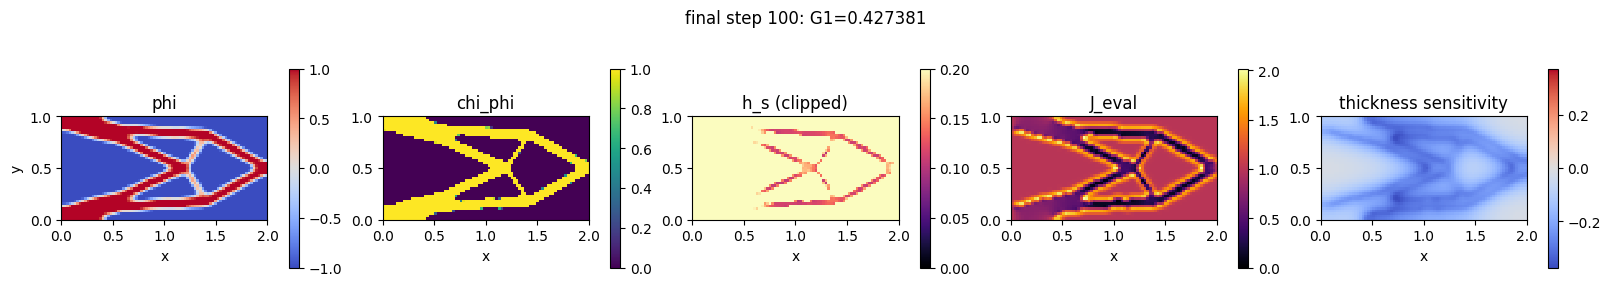

step=01 compliance=306.18 volume=0.90 G1=0.86 lambda_h=200.00 S_comp=1.53e+02 S_thick=2.61e+01 S_ratio=1.71e-01 cos=-0.555
step=02 compliance=4730.95 volume=0.90 G1=0.42 lambda_h=200.86 S_comp=2.37e+03 S_thick=2.75e+01 S_ratio=1.16e-02 cos=-0.207
step=03 compliance=3399.26 volume=0.90 G1=0.57 lambda_h=201.28 S_comp=1.70e+03 S_thick=3.34e+01 S_ratio=1.97e-02 cos=-0.293
step=04 compliance=339.68 volume=0.90 G1=0.71 lambda_h=201.86 S_comp=1.70e+02 S_thick=3.87e+01 S_ratio=2.28e-01 cos=-0.507
step=05 compliance=239.29 volume=0.90 G1=0.66 lambda_h=202.57 S_comp=1.20e+02 S_thick=3.72e+01 S_ratio=3.11e-01 cos=-0.556
step=06 compliance=187.04 volume=0.90 G1=0.69 lambda_h=203.23 S_comp=9.35e+01 S_thick=3.83e+01 S_ratio=4.10e-01 cos=-0.549
step=07 compliance=166.75 volume=0.90 G1=0.67 lambda_h=203.92 S_comp=8.34e+01 S_thick=3.82e+01 S_ratio=4.58e-01 cos=-0.584
step=08 compliance=143.24 volume=0.90 G1=0.68 lambda_h=204.58 S_comp=7.16e+01 S_thick=3.71e+01 S_ratio=5.18e-01 cos=-0.599
step=09 compli

In [9]:
weights = precompute.nodal_weights

def weighted_mean_abs(values):
    return float(np.dot(weights, np.abs(values)) / np.sum(weights))

def weighted_cosine(a, b):
    numerator = np.dot(weights, a * b)
    denominator = np.sqrt(
        np.dot(weights, a * a)
        * np.dot(weights, b * b)
    )
    return numerator / denominator

compliance_history = []
volume_history = []
g1_history = [initial_thickness.constraint]
lambda_thickness_history = [thickness_params.lambda_thickness]
analysis = initial_thickness

progress_styles = [
    ('phi', 'coolwarm', -1.0, 1.0),
    ('chi_phi', 'viridis', 0.0, 1.0),
    ('h_s (clipped)', 'magma', 0.0, 2.0 * thickness_params.h0),
    ('J_eval', 'inferno', 0.0, max(float(np.max(analysis.evaluation)), 1.0e-12)),
    ('thickness sensitivity', 'coolwarm', -1.0, 1.0),
]
progress_fields = [
    phi, analysis.characteristic,
    np.clip(analysis.thickness, 0.0, 2.0 * thickness_params.h0),
    analysis.evaluation, analysis.sensitivity,
]
progress_fig, progress_axes = plt.subplots(1, 5, figsize=(16, 3), constrained_layout=True)
progress_images = []
progress_colorbars = []
for ax, values, (title, cmap, vmin, vmax) in zip(progress_axes, progress_fields, progress_styles):
    image = ax.imshow(
        values.reshape(ny + 1, nx + 1), origin='lower', extent=[0, lx, 0, ly],
        aspect='equal', cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest',
    )
    ax.set_title(title)
    ax.set_xlabel('x')
    progress_images.append(image)
    progress_colorbars.append(progress_fig.colorbar(image, ax=ax, shrink=0.75))
progress_axes[0].set_ylabel('y')
progress_fig.suptitle('step 0')
progress_display = display(progress_fig, display_id=True)
plt.close(progress_fig)

for step in range(n_steps):
    result = step_min_compliance(
        mesh=mesh, material=material, phi=phi, params=rd_params,
        fixed_displacement_nodes=left_nodes, nodal_forces=nodal_forces,
        fixed_phi_nodes=fixed_phi_nodes, smooth_heaviside_width=1e-3,
        update_lambda=True, volume_tolerance=2.0e-3, precompute=precompute,
        maximum_thickness_params=thickness_params, update_thickness_lambda=True,
        maximum_thickness_helmholtz_solver=helmholtz_solver,
    )
    analysis = result.maximum_thickness_result
    if analysis is None:
        raise RuntimeError('maximum thickness result is missing')
    if step > 0:
        g1_history.append(analysis.constraint)
        lambda_thickness_history.append(thickness_params.lambda_thickness)
    compliance_history.append(result.compliance)
    volume_history.append(result.objective.volume)
    progress_fields = [
        phi, analysis.characteristic,
        np.clip(analysis.thickness, 0.0, 2.0 * thickness_params.h0),
        analysis.evaluation, analysis.sensitivity,
    ]
    for image, colorbar, values in zip(progress_images, progress_colorbars, progress_fields):
        image.set_data(values.reshape(ny + 1, nx + 1))
        colorbar.update_normal(image)
    progress_images[3].set_clim(0.0, max(float(np.max(analysis.evaluation)), 1.0e-12))
    sensitivity_limit = max(float(np.max(np.abs(analysis.sensitivity))), 1.0e-12)
    progress_images[4].set_clim(-sensitivity_limit, sensitivity_limit)
    progress_colorbars[3].update_normal(progress_images[3])
    progress_colorbars[4].update_normal(progress_images[4])
    progress_fig.suptitle(
        f'step {step + 1}: compliance={result.compliance:.5f}, '
        f'volume={result.objective.volume:.5f}, G1={analysis.constraint:.6f}'
    )
    progress_fig.canvas.draw_idle()
    if progress_display is not None:
        progress_display.update(progress_fig)

    # sensitivity analysis 
    s_comp = weighted_mean_abs(result.sensitivity)
    s_thick = weighted_mean_abs(result.thickness_sensitivity)
    s_ratio = s_thick / s_comp if s_comp > 0.0 else np.nan
    cosine = weighted_cosine(
        result.sensitivity,
        result.thickness_sensitivity,
    )

    print(
        f'step={step + 1:02d} compliance={result.compliance:.2f} '
        f'volume={result.objective.volume:.2f} G1={analysis.constraint:.2f} '
        f'lambda_h={thickness_params.lambda_thickness:.2f} '
        f'S_comp={s_comp:.2e} S_thick={s_thick:.2e} '
        f'S_ratio={s_ratio:.2e} ' 
        f'cos={cosine:.3f}'
    )
    phi = result.phi_next
    rd_params = replace(rd_params, lambda_value=result.lambda_value)
    thickness_params = replace(thickness_params, lambda_thickness=result.thickness_lambda)

final_analysis = analyze_maximum_thickness(
    mesh, phi, thickness_params,
    precompute=precompute,
    helmholtz_solver=helmholtz_solver,
)
g1_history.append(final_analysis.constraint)
lambda_thickness_history.append(thickness_params.lambda_thickness)
progress_fields = [
    phi, final_analysis.characteristic,
    np.clip(final_analysis.thickness, 0.0, 2.0 * thickness_params.h0),
    final_analysis.evaluation, final_analysis.sensitivity,
]
for image, colorbar, values in zip(progress_images, progress_colorbars, progress_fields):
    image.set_data(values.reshape(ny + 1, nx + 1))
    colorbar.update_normal(image)
progress_images[3].set_clim(0.0, max(float(np.max(final_analysis.evaluation)), 1.0e-12))
sensitivity_limit = max(float(np.max(np.abs(final_analysis.sensitivity))), 1.0e-12)
progress_images[4].set_clim(-sensitivity_limit, sensitivity_limit)
progress_colorbars[3].update_normal(progress_images[3])
progress_colorbars[4].update_normal(progress_images[4])
progress_fig.suptitle(f'final step {n_steps}: G1={final_analysis.constraint:.6f}')
progress_fig.canvas.draw_idle()
if progress_display is not None:
    progress_display.update(progress_fig)

assert len(compliance_history) == n_steps
assert len(g1_history) == n_steps + 1
assert len(lambda_thickness_history) == n_steps + 1
assert np.all(np.isfinite(g1_history))
assert result.thickness_sensitivity is not None


## History plots

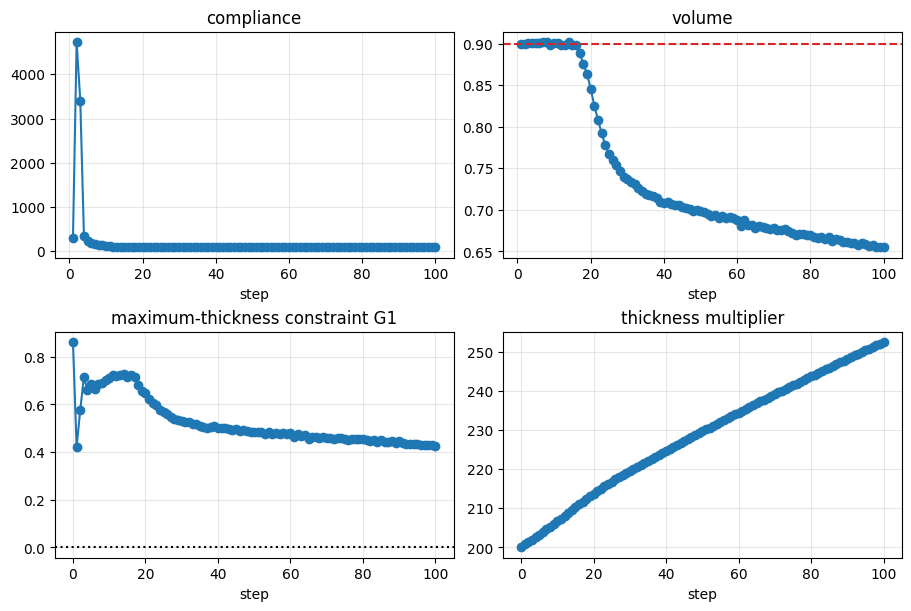

G1 change: 0.861674 -> 0.427381


In [10]:
steps = np.arange(1, n_steps + 1)
constraint_steps = np.arange(0, n_steps + 1)
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True)
axes[0, 0].plot(steps, compliance_history, marker='o')
axes[0, 0].set_title('compliance')
axes[0, 1].plot(steps, volume_history, marker='o')
axes[0, 1].axhline(rd_params.v_max, color='tab:red', linestyle='--')
axes[0, 1].set_title('volume')
axes[1, 0].plot(constraint_steps, g1_history, marker='o')
axes[1, 0].axhline(0.0, color='black', linestyle=':')
axes[1, 0].set_title('maximum-thickness constraint G1')
axes[1, 1].plot(constraint_steps, lambda_thickness_history, marker='o')
axes[1, 1].set_title('thickness multiplier')
for ax in axes.ravel():
    ax.set_xlabel('step')
    ax.grid(True, alpha=0.3)
plt.show()
print(f'G1 change: {g1_history[0]:.6f} -> {g1_history[-1]:.6f}')


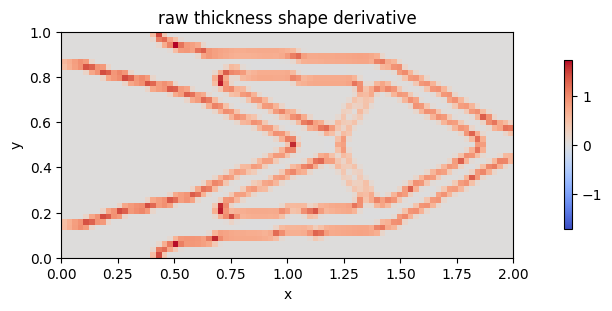

In [11]:
fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
shape_derivative = final_analysis.shape_derivative
limit = max(float(np.max(np.abs(shape_derivative))), 1.0e-12)
image = ax.imshow(
    shape_derivative.reshape(ny + 1, nx + 1),
    origin="lower",
    extent=[0, lx, 0, ly],
    aspect="equal",
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
    interpolation="nearest",
)
ax.set_title("raw thickness shape derivative")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(image, ax=ax, shrink=0.75)
plt.show()